# Phase 2: Statistical analysis:

First, we set up the environment with the necessary libraries:

In [ ]:
# Libraries for data processing:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None) # To be able to see all columns from the data frames

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, kstest

import warnings
warnings.filterwarnings("ignore")

In [83]:
# Load the clean csv files as dataframes:

df_flights = pd.read_csv("clean-data/customer-flight-activity-clean.csv")
df_customers = pd.read_csv("clean-data/customer-loyal-history-clean.csv")
df_master = pd.read_csv("clean-data/merged-master-data-clean.csv")
df_merged_high_salaries = pd.read_csv("clean-data/merged-high-salaries-clean.csv")
df_flights_booked = pd.read_csv("clean-data/flights-booked-not-zero.csv")

In [84]:
display(df_flights.head(3))
print("="*150)
display(df_customers.head(3))
print("="*150)
display(df_master.head(3))
print("="*150)
display(df_merged_high_salaries.head(3))
print("="*150)
display(df_flights_booked.head(3))

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,January,3,0,3,1521,152.0,0,0
1,100102,2017,January,10,4,14,2030,203.0,0,0
2,100140,2017,January,6,0,6,1200,120.0,0,0


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,active_customer,salary_category
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,True,normal
1,100102,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,March,True,normal
2,100140,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,July,False,normal


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,active_customer,salary_category,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,True,normal,2017,January,3,0,3,1521,152.0,0,0
1,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,True,normal,2017,February,2,2,4,1320,132.0,0,0
2,100018,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,February,True,normal,2018,October,6,4,10,3110,311.0,385,31


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,active_customer,salary_category,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,102740,Canada,Ontario,Trenton,K8V 4B2,Female,Doctor,163974.0,Married,Star,3936.79,Standard,2013,December,NaN,NaN,True,high_outliers,2017,January,0,0,0,0,0.0,0,0
1,102740,Canada,Ontario,Trenton,K8V 4B2,Female,Doctor,163974.0,Married,Star,3936.79,Standard,2013,December,NaN,NaN,True,high_outliers,2017,February,0,0,0,0,0.0,0,0
2,102740,Canada,Ontario,Trenton,K8V 4B2,Female,Doctor,163974.0,Married,Star,3936.79,Standard,2013,December,NaN,NaN,True,high_outliers,2017,March,0,0,0,0,0.0,0,0


,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,January,3,0,3,1521,152.0,0,0
1,100102,2017,January,10,4,14,2030,203.0,0,0
2,100140,2017,January,6,0,6,1200,120.0,0,0


## 1. Numerical variables analysis

### 1. Descriptive statistics (mean, median, mode, standard deviation etc)

Let's start with the customers dataframe:

In [85]:
df_customers.describe().T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,14778.0,544466.324063,257120.753932,100018.00,322463.500,545886.00,765441.5000,996989.00
salary,11027.0,79451.765213,35004.191059,15609.00,59221.500,73398.00,88595.0000,407228.00
clv,14778.0,8003.704467,6900.522938,1898.01,3964.245,5780.18,8995.7725,83325.38
enrollment_year,14778.0,2015.250711,1.983899,2012.00,2014.000,2015.00,2017.0000,2018.00


In [86]:
relevant_numerical_customers = ["salary", "clv", "enrollment_year"]
relevant_numerical_customers

['salary', 'clv', 'enrollment_year']

In [87]:
df_customers[relevant_numerical_customers].describe().T
# Salary:
    # As previously seen during phase 1. The count of salaries is less since some of the values are null. 
    # The mean and median (50% in the table) differ a bit. It seems the extreme high salary values are bring the mean to the right. 
# clv: 
    # The mean and median differ. Same as with the salary, the high extreme values are bringing the mean to the right. 
# enrollment_year:
    # For this variable, the only "relevant" information is to know that the earliest enrolllment year was in 2012 and the latest in 2018.


,count,mean,std,min,25%,50%,75%,max
salary,11027.0,79451.765213,35004.191059,15609.00,59221.500,73398.00,88595.0000,407228.00
clv,14778.0,8003.704467,6900.522938,1898.01,3964.245,5780.18,8995.7725,83325.38
enrollment_year,14778.0,2015.250711,1.983899,2012.00,2014.000,2015.00,2017.0000,2018.00


In [88]:
mean_salary = round(df_customers["salary"].mean(),2)
median_salary = round(df_customers["salary"].median(),2)

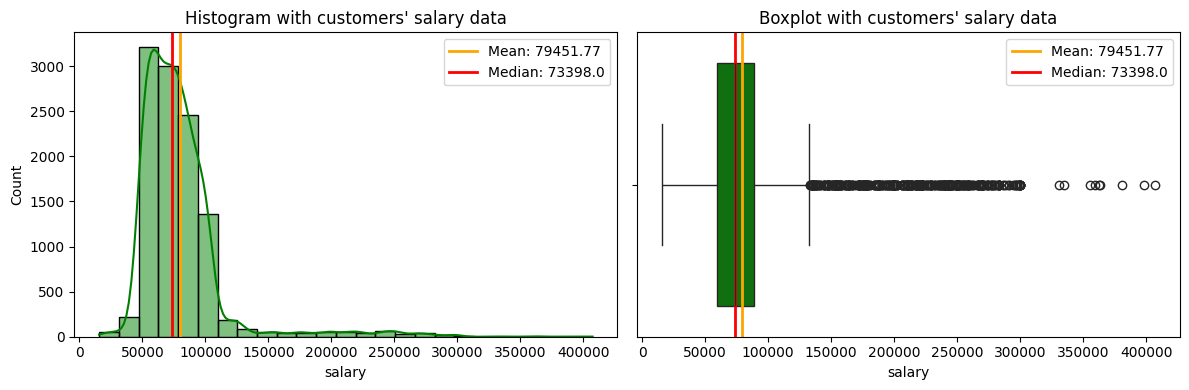

In [128]:
# Let's visualize the salary mean and median with an histogram and a boxplot below:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
# Histogram
sns.histplot(data=df_customers, x= "salary", bins=25, color ="green",ax=axes[0],kde=True)
axes[0].axvline(mean_salary, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_salary}")
axes[0].axvline(median_salary, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_salary}")
axes[0].legend()
axes[0].set_title("Histogram with customers' salary data")

# Boxplot
sns.boxplot(data=df_customers, x= "salary", color ="green",ax=axes[1])
axes[1].axvline(mean_salary, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_salary}")
axes[1].axvline(median_salary, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_salary}")
axes[1].set_title("Boxplot with customers' salary data");
axes[1].legend()

plt.tight_layout()
plt.show();

In [90]:
# As identified when looking at the df.describe():
# With the histogram we can see the distribution of the customers' salaries. Most of the salaries are in the lower range. 
# The distribution is right-skweded (the very few high salaries are extending the tail to the right --> mean higher than the median).
# The boxplot also shows the salary distribution and helps us identify the outliers.
# The "box" (interquartile range) is towards the lower values, meaning that most of the customers have lower salaries.
# There are many outliers on the right side which influence the whole distribution.

In [91]:
# LET'S ANALYSE SOME DISPERSION MEASUREMENTS:
var_salary = round(df_customers["salary"].var(),2)
std_salary = round(df_customers["salary"].std(),2)
print(f"The variance of the salary is: {var_salary}.")
print(f"The standard deviation of the salary is: {std_salary}.")

The variance of the salary is: 1225293391.69.
The standard deviation of the salary is: 35004.19.


In [92]:
# Both assess the dispersion of the values in comparison with the mean. 
# However, the standard deviation provide us the value in the same unit as the data. 
# To be able to compare different data, it is better to use the coefficient of variation (CV) which is the ration between the standard deviation and the mean.

In [79]:
# SALARY CV CALCULATION:
cv_salary = round(std_salary / mean_salary * 100,2)
print(f"The coefficient of variance (CV) is {cv_salary}.")
# Values above 30 mean that there is a high dispersion of the data (expected after seeing the histogram and boxplot).

The coefficient of variance (CV) is 44.06.


Let's do the same for the flights dataframe (the one with flights booked > 0): 

In [93]:
relevant_numerical_flights = ["total_flights","flights_with_companions","distance","points_accumulated"]
relevant_numerical_flights

['total_flights', 'flights_with_companions', 'distance', 'points_accumulated']

In [94]:
df_flights_booked[relevant_numerical_flights].describe().T


,count,mean,std,min,25%,50%,75%,max
total_flights,207632.0,10.054756,5.807808,1.0,6.0,10.0,14.0,32.0
flights_with_companions,207632.0,2.015706,2.538359,0.0,0.0,1.0,4.0,11.0
distance,207632.0,2361.633876,1135.835170,90.0,1458.0,2298.0,3150.0,6293.0
points_accumulated,207632.0,241.642600,116.118272,9.0,149.0,235.0,323.0,676.5


In [ ]:
# With this dataframe, we can see that the mean and the median are very similar. similar tren with the distance and points accumulated.
# The flights with companion follow a different trend. Customers who usually travel with companion are influencing the dataset (mean is higher than the median)

In [95]:
mean_distance = round(df_flights_booked["distance"].mean(),2)
median_distance = round(df_flights_booked["distance"].median(),2)

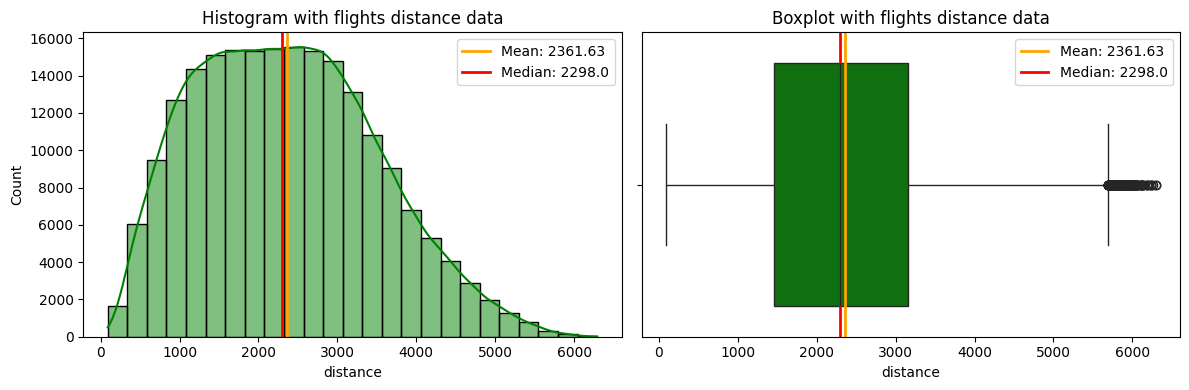

In [98]:
# Let's visualize the distance mean and median with an histogram and a boxplot below:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
# Histogram
sns.histplot(data=df_flights_booked, x= "distance", bins=25, color ="green",ax=axes[0],kde=True)
axes[0].axvline(mean_distance, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_distance}")
axes[0].axvline(median_distance, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_distance}")
axes[0].legend()
axes[0].set_title("Histogram with flights distance data")

# Boxplot
sns.boxplot(data=df_flights_booked, x= "distance", color ="green",ax=axes[1])
axes[1].axvline(mean_distance, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_distance}")
axes[1].axvline(median_distance, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_distance}")
axes[1].set_title("Boxplot with flights distance data");
axes[1].legend()

plt.tight_layout()
plt.show();

In [ ]:
# HISTOGRAM:
    # We can see a normal distribution. The mean and the median are close together and it seems there are a few outliers (although the histogram is quite symmetrical, it is a bit right-skweded)
# BOXPLOT:
    # We can also see the distance distribution here. With the boxplot we can easily identify the outliers on the upper range. The majority of the flights have a flight distance betwwen 1500 to 3200. 
    # We would need to contact the company to clarify whether the distance is recorded in Km or in miles.


In [99]:
# LET'S ANALYSE THE DISPERSION MEASUREMENTS:
var_distance = round(df_flights_booked["distance"].var(),2)
std_distance = round(df_flights_booked["distance"].std(),2)
print(f"The variance of the distance is: {var_distance}.")
print(f"The standard deviation of the dsitance is: {std_distance}.")

The variance of the distance is: 1290121.53.
The standard deviation of the dsitance is: 1135.84.


In [ ]:
# Both assess the dispersion of the values in comparison with the mean. 
# However, the standard deviation provide us the value in the same unit as the data. 
# To be able to compare different data, it is better to use the coefficient of variation (CV) which is the ration between the standard deviation and the mean.

In [ ]:
# DISTANCE CV CALCULATION:
cv_distance = round(std_distance / mean_distance * 100,2)
print(f"The coefficient of variance (CV) is {cv_distance}.")
# Values above 30 mean that there is a high dispersion of the data (expected after seeing the histogram and boxplot). This implies a wide range of distances.

The coefficient of variance (CV) is 48.1.


### 2. Outlier values identification

Customers dataframe:

In [22]:
IQR_salary = df_customers["salary"].quantile(0.75) - df_customers["salary"].quantile(0.25)

salary_inferior_limit = df_customers["salary"].quantile(0.25) - 1.5 * IQR_salary
salary_superior_limit = df_customers["salary"].quantile(0.75) + 1.5 * IQR_salary

superior_mask_salary = df_customers["salary"] > salary_superior_limit
inferior_mask_salary = df_customers["salary"] < salary_inferior_limit

outliers_filter_salary = df_customers[inferior_mask_salary | superior_mask_salary]

outliers_filter_salary["salary"].describe()

count       471.000000
mean     213834.507431
std       49488.443663
min      133080.000000
25%      174791.000000
50%      211255.000000
75%      250152.000000
max      407228.000000
Name: salary, dtype: float64

In [23]:
# We have 471 outliers where the min value is 133000 and the maximum value is 407228.
# There are not many outliers but they have a strong influence on the salary distribution.

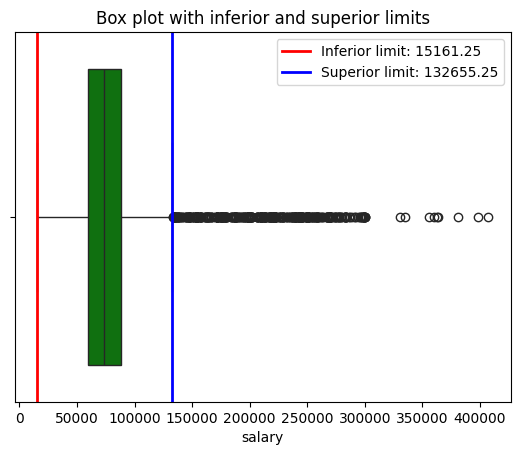

In [110]:
sns.boxplot(data=df_customers, x = "salary", color="green")

plt.axvline(round(salary_inferior_limit,2) , color = "red", linestyle = "-", linewidth = 2, label = f"Inferior limit: {round(salary_inferior_limit,2)}")
plt.axvline(round(salary_superior_limit,2), color = "blue", linestyle = "-", linewidth = 2, label = f"Superior limit: {round(salary_superior_limit,2)}")
plt.title("Box plot with inferior and superior limits")
plt.legend();

In [107]:
IQR_distance = df_flights_booked["distance"].quantile(0.75) - df_flights_booked["distance"].quantile(0.25)

distance_inferior_limit = df_flights_booked["distance"].quantile(0.25) - 1.5 * IQR_distance
distance_superior_limit = df_flights_booked["distance"].quantile(0.75) + 1.5 * IQR_distance

superior_mask_distance = df_flights_booked["distance"] > distance_superior_limit
inferior_mask_distance = df_flights_booked["distance"] < distance_inferior_limit

outliers_filter_distance = df_flights_booked[inferior_mask_distance | superior_mask_distance]

outliers_filter_distance["distance"].describe()

count     275.000000
mean     5856.112727
std       134.201661
min      5691.000000
25%      5741.000000
50%      5850.000000
75%      5928.000000
max      6293.000000
Name: distance, dtype: float64

### 3. Correlation analysis

In [112]:
df_master.describe().T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,356685.0,544619.920465,257183.862038,100018.00,322606.00,546025.00,765518.00,996989.00
salary,266216.0,79425.244587,34972.533255,15609.00,59223.00,73382.00,88516.00,407228.00
clv,356685.0,8015.646214,6913.323946,1898.01,3964.81,5783.18,9007.43,83325.38
enrollment_year,356685.0,2015.250411,1.983920,2012.00,2014.00,2015.00,2017.00,2018.00
year,356685.0,2017.500405,0.500001,2017.00,2017.00,2018.00,2018.00,2018.00
flights_booked,356685.0,4.207303,5.246773,0.00,0.00,1.00,8.00,21.00
flights_with_companions,356685.0,1.051670,2.092229,0.00,0.00,0.00,1.00,11.00
total_flights,356685.0,5.258974,6.544493,0.00,0.00,2.00,10.00,32.00
distance,356685.0,1236.607416,1438.427520,0.00,0.00,636.00,2375.00,6293.00
points_accumulated,356685.0,126.531094,147.140796,0.00,0.00,65.00,243.00,676.50


In [114]:
numerical_master = df_master.select_dtypes(include="number")
numerical_master

,loyalty_number,salary,clv,enrollment_year,year,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,83236.0,3839.14,2016,2017,3,0,3,1521,152.0,0,0
1,100018,83236.0,3839.14,2016,2017,2,2,4,1320,132.0,0,0
2,100018,83236.0,3839.14,2016,2018,6,4,10,3110,311.0,385,31
3,100018,83236.0,3839.14,2016,2017,4,0,4,924,92.0,0,0
4,100018,83236.0,3839.14,2016,2017,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
356680,990947,75049.0,83325.38,2015,2018,0,0,0,0,0.0,0,0
356681,990947,75049.0,83325.38,2015,2018,0,0,0,0,0.0,0,0
356682,990947,75049.0,83325.38,2015,2018,0,0,0,0,0.0,0,0
356683,990947,75049.0,83325.38,2015,2018,0,0,0,0,0.0,0,0


In [115]:
# I will use the merged master dataframe to analize the correlation between numerical variables:
matrix_master = numerical_master.corr()
matrix_master

,loyalty_number,salary,clv,enrollment_year,year,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
loyalty_number,1.000000,-0.013121,0.113402,0.001316,0.000433,0.001316,-0.000882,0.000773,0.001944,0.001911,0.002321,0.002318
salary,-0.013121,1.000000,-0.018170,-0.029231,-0.000193,-0.002195,-0.000096,-0.001791,-0.001841,-0.001961,-0.004241,-0.004244
clv,0.113402,-0.018170,1.000000,-0.003083,0.000317,0.001429,0.001609,0.001660,0.002691,0.002804,0.002185,0.002197
enrollment_year,0.001316,-0.029231,-0.003083,1.000000,-0.000173,0.007023,0.005098,0.007260,0.007110,0.007502,0.001054,0.001042
year,0.000433,-0.000193,0.000317,-0.000173,1.000000,0.060585,0.032936,0.059101,0.073569,0.092602,0.029029,0.029043
flights_booked,0.001316,-0.002195,0.001429,0.007023,0.060585,1.000000,0.497581,0.960781,0.763886,0.756573,0.185084,0.185093
flights_with_companions,-0.000882,-0.000096,0.001609,0.005098,0.032936,0.497581,1.000000,0.718608,0.513230,0.506351,0.330567,0.330630
total_flights,0.000773,-0.001791,0.001660,0.007260,0.059101,0.960781,0.718608,1.000000,0.776490,0.768427,0.254063,0.254090
distance,0.001944,-0.001841,0.002691,0.007110,0.073569,0.763886,0.513230,0.776490,1.000000,0.994479,0.220548,0.220571
points_accumulated,0.001911,-0.001961,0.002804,0.007502,0.092602,0.756573,0.506351,0.768427,0.994479,1.000000,0.219782,0.219817


In [ ]:
# With the correlation matrix we can see the correlation coeficients for each combination of numerical pairs. 
# The closer the coefficient is to 1, stronger is the correlation (closer to -1: stronger negative correlation / closer to +1: stronger positive correlation)

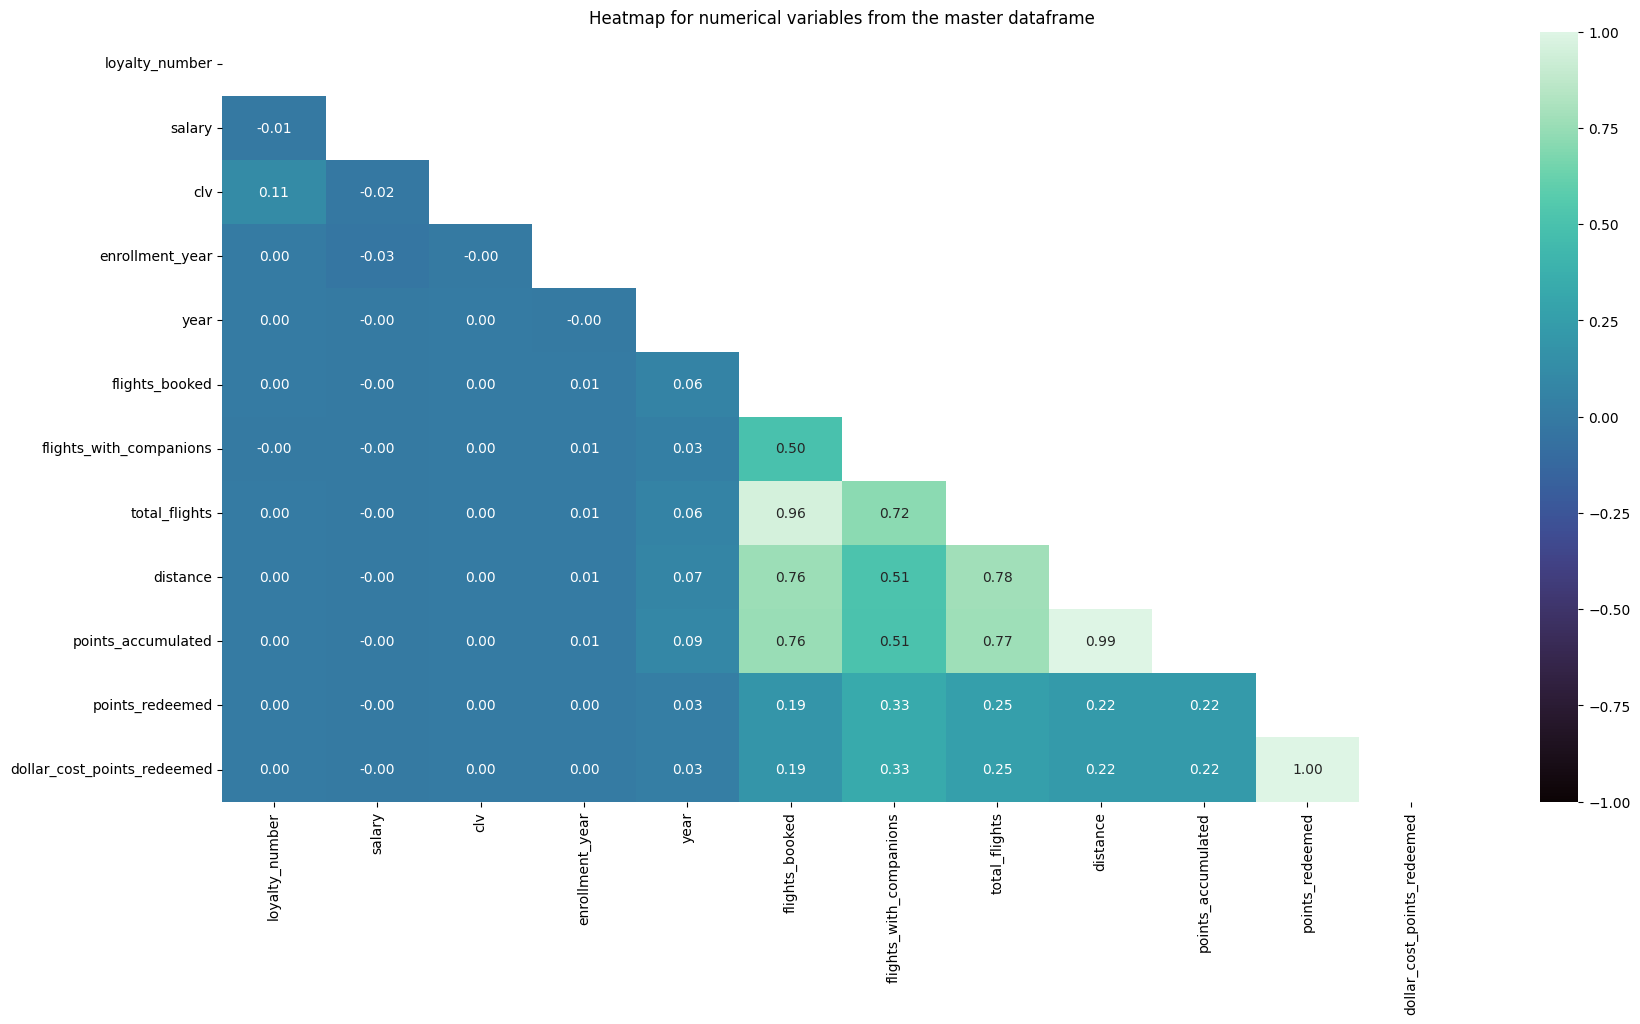

In [118]:
# For a better visualization and identification of these stron correlations, it is better to do a heatmap: 

plt.figure(figsize=(20,10)) 
mask = np.triu(np.ones_like(matrix_master, dtype=bool)) # to remove the duplicates

sns.heatmap(matrix_master, annot=True, fmt='.2f', cmap="mako", vmin=-1, vmax=1,mask=mask)
plt.title("Heatmap for numerical variables from the master dataframe");  

In [ ]:
# The variables with the strongest correlation are the below (all positive: meaning when one increases, the other one increases as well):
    # points_redeeemed and dollar_cost_points_redeemed
    # distance with points_accumulated
    # total_flights with distance 
    # total_flights with points_accumulated 


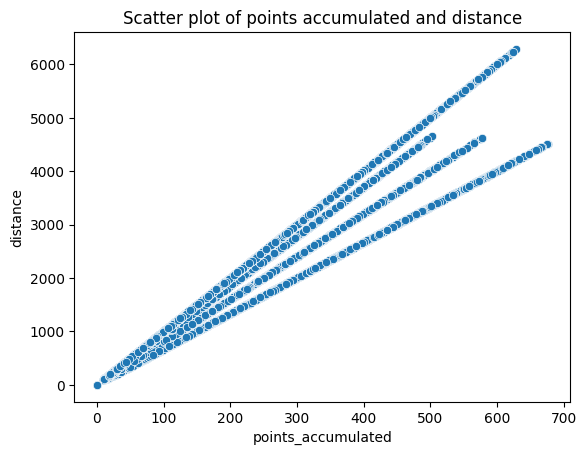

In [ ]:
# SCATTERPLOT points_accumulared with distance:
sns.scatterplot(data=df_master, x="points_accumulated", y="distance")
plt.title("Scatter plot of points accumulated and distance");
# We can see the strong positive correlation. Definitely the distance is a strong factors to accumulate points.

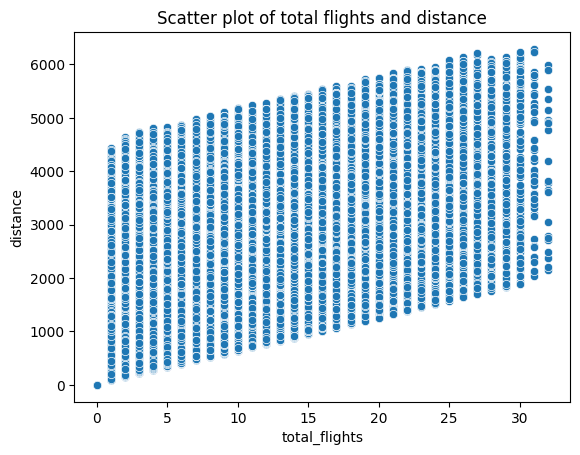

In [ ]:
# SCATTERPLOT total_flights with distance:
sns.scatterplot(data=df_master, x="total_flights", y="distance")
plt.title("Scatter plot of total flights and distance");
# We can see clearly the postiive correlation, the highter the N of total flights, higher the distance.

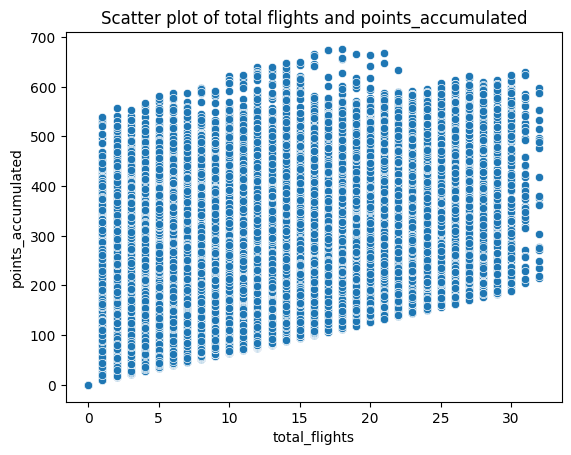

In [ ]:
# SCATTERPLOT total_flights with points_accumulated:
sns.scatterplot(data=df_master, x="total_flights", y="points_accumulated")
plt.title("Scatter plot of total flights and points_accumulated"); #We can also see the positive correlation between both variables.

## 2. Categorical variables analysis

### Frequencies distribution

In [ ]:
df_master.describe(exclude="number").T # I want to see also the boolean variable (active_customer)

,count,unique,top,freq
country,356685,1,Canada,356685
province,356685,11,Ontario,114855
city,356685,29,Toronto,71608
postal_code,356685,55,V6E 3D9,19079
gender,356685,2,Female,179269
education,356685,5,Bachelor,223240
marital_status,356685,3,Married,207646
loyalty_card,356685,3,Star,165993
enrollment_type,356685,2,Standard,335786
enrollment_month,356685,12,May,32140


In [ ]:
df_merged_high_salaries.describe(exclude="number").T # I want to see also the boolean variable (active_customer)

,count,unique,top,freq
country,12779,1,Canada,12779
province,12779,11,Ontario,4029
city,12779,29,Toronto,2277
postal_code,12779,54,V6E 3Z3,720
gender,12779,2,Female,6422
education,12779,2,Doctor,12731
marital_status,12779,3,Married,8253
loyalty_card,12779,3,Star,6207
enrollment_type,12779,2,Standard,12011
enrollment_month,12779,12,September,1406


In [140]:
absolute_education_normal = df_master["education"].value_counts()
absolute_education_high_salary = df_merged_high_salaries["education"].value_counts()
relative_education_normal = round(df_master["education"].value_counts(normalize=True)*100,2)
relative_education_high_salary = round(df_merged_high_salaries["education"].value_counts(normalize=True)*100,2)


In [ ]:
column_index = absolute_education_normal.index #to get the indexes 
column_absolute = absolute_education_normal.values
column_relative = relative_education_normal.values

print(column_index)
print(column_absolute)
print(column_relative)

Index(['Bachelor', 'College', 'High School or Below', 'Doctor', 'Master'], dtype='str', name='education')
[223240  90013  16759  15735  10938]
[62.59 25.24  4.7   4.41  3.07]


In [143]:
freq_table_edu_normal = pd.DataFrame({"Education": column_index, 
                                          "Absolute frequency": column_absolute, 
                                          "Relative frequency": column_relative})
print("Frequencies table from the master data frame:")
display(freq_table_edu_normal)

Frequencies table from the master data frame:


,Education,Absolute frequency,Relative frequency
0,Bachelor,223240,62.59
1,College,90013,25.24
2,High School or Below,16759,4.70
3,Doctor,15735,4.41
4,Master,10938,3.07


In [144]:
# I do the same with the dataframe that includes only the high salaries:
column_index_high = absolute_education_high_salary.index #to get the indexes 
column_absolute_high = absolute_education_high_salary.values
column_relative_high = relative_education_high_salary.values

print(column_index_high)
print(column_absolute_high)
print(column_relative_high)

Index(['Doctor', 'Master'], dtype='str', name='education')
[12731    48]
[99.62  0.38]


In [146]:
freq_table_edu_high = pd.DataFrame({"Education": column_index_high, 
                                          "Absolute frequency": column_absolute_high, 
                                          "Relative frequency": column_relative_high})
print("Frequencies table from the data frame with high salaries only:")
display(freq_table_edu_high)

Frequencies table from the data frame with high salaries only:


,Education,Absolute frequency,Relative frequency
0,Doctor,12731,99.62
1,Master,48,0.38


In [ ]:
# If we compare both frequencies table we can clearly see that the customers with the highest salaries have only high education level (doctors and masters).
# Whereas on the master dataframe, we can see that the relative frequency (%) of doctors and customers with a master is way less. 

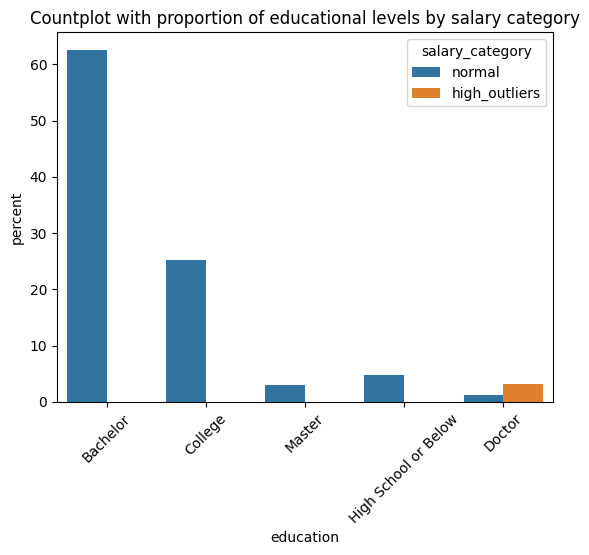

In [150]:
sns.countplot(data=df_master, x= "education", stat="percent", hue = "salary_category")
plt.title("Countplot with proportion of educational levels by salary category")
plt.xticks(rotation=45);

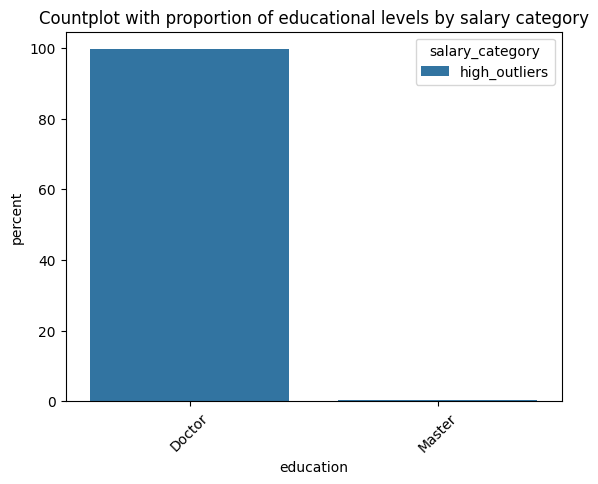

In [151]:
sns.countplot(data=df_merged_high_salaries, x= "education", stat="percent", hue = "salary_category")
plt.title("Countplot with proportion of educational levels by salary category")
plt.xticks(rotation=45);

In [ ]:
# With the countplots we can see exactly the same information as with the frequency tables. 

In [ ]:
# Is there any relationship with the loyalty card and being an active customer?
pd.crosstab(df_master["loyalty_card"], df_master["active_customer"])

active_customer,False,True
loyalty_card,,
Aurora,9112,61855
Nova,15224,104501
Star,19708,146285


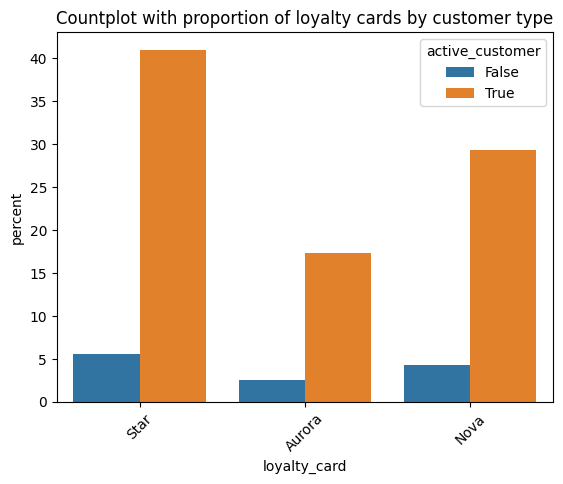

In [159]:
sns.countplot(data=df_master, x= "loyalty_card", stat="percent", hue = "active_customer")
plt.title("Countplot with proportion of loyalty cards by customer type")
plt.xticks(rotation=45);

In [ ]:
# I do not see a clear pattern. A similar proportion of each loyalty cards are inactive customers.

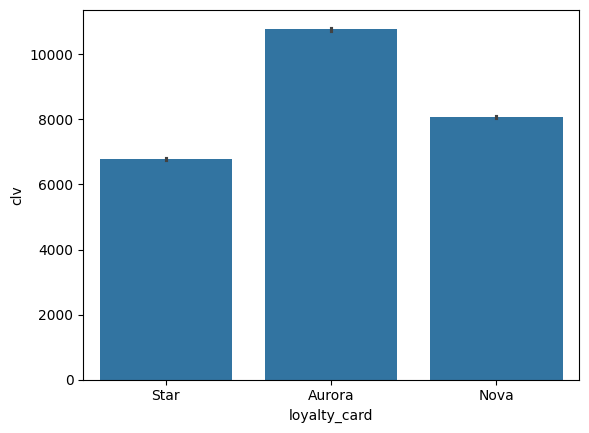

In [ ]:
# Is there any relationship between the loyalty card and the customer life time value (clv)?
# I need to use a barplot because we are analyzing a categorical variable (loyalty_card) with a numerical (clv):
sns.barplot(data=df_master,x="loyalty_card",y="clv",estimator='mean');
     
     

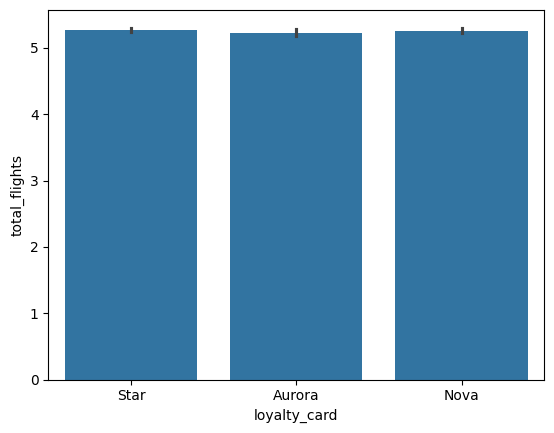

In [ ]:
# I can see in the graph that customers with an Aurora card have a higher mean of CLV. 
# I would need to clarfiy with the company on how these card are issued to be able to say if they are issuing them right. 
# Let's see if there is any pattern with the total number of flights and the clv:
sns.barplot(data=df_master,x="loyalty_card",y="total_flights",estimator='mean');

In [ ]:
# No clear pattern. The mean N of total flights is very similar for each loyalty card. Unclear the rationale behind issuing the cards. 